In [103]:
!pip install -q -U watermark

In [104]:
# Imports
import re
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [105]:
%reload_ext watermark
%watermark -a "Eduardo Lyrio"

Author: Eduardo Lyrio



### **Carregando os dados e Compreendendo as variáveis**

In [106]:
# Carregando os dados
df_dsa = pd.read_csv("dataset.csv")

In [107]:
# Shape
df_dsa.shape

(101766, 50)

In [108]:
df_dsa.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222167,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [109]:
df_dsa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [110]:
# Verificando valores nulos (ausentes)
df_dsa.isnull().sum()

,0
encounter_id,0
patient_nbr,0
race,0
gender,0
age,0
weight,0
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0


In [111]:
# Checando as colunas que tem valor = '?'
df_dsa.isin(['?']).any()

,0
encounter_id,False
patient_nbr,False
race,True
gender,False
age,False
weight,True
admission_type_id,False
discharge_disposition_id,False
admission_source_id,False
time_in_hospital,False


In [112]:
df_dsa.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')

In [113]:
# Verificando valores únicos
for col in list(df_dsa.columns):

    #Obtém uma lista de valores únicos
    list_of_unique_values = df_dsa[col].unique()

    #Se o numero de valores exclusivos for menor que 15, imprima os valores.
    # Caso contrario, imprima o numero de valores exclusivos
    if len(list_of_unique_values) < 15:
        print("\n")
        print(col + ': ' + str(len(list_of_unique_values)) + 'valores únicos')
        print(list_of_unique_values)
    else:
        print("\n")
        print(col + ': ' + str(len(list_of_unique_values)) + 'valores únicos')




encounter_id: 101766valores únicos


patient_nbr: 71518valores únicos


race: 6valores únicos
['Caucasian' 'AfricanAmerican' '?' 'Other' 'Asian' 'Hispanic']


gender: 3valores únicos
['Female' 'Male' 'Unknown/Invalid']


age: 10valores únicos
['[0-10)' '[10-20)' '[20-30)' '[30-40)' '[40-50)' '[50-60)' '[60-70)'
 '[70-80)' '[80-90)' '[90-100)']


weight: 10valores únicos
['?' '[75-100)' '[50-75)' '[0-25)' '[100-125)' '[25-50)' '[125-150)'
 '[175-200)' '[150-175)' '>200']


admission_type_id: 8valores únicos
[6 1 2 3 4 5 8 7]


discharge_disposition_id: 26valores únicos


admission_source_id: 17valores únicos


time_in_hospital: 14valores únicos
[ 1  3  2  4  5 13 12  9  7 10  6 11  8 14]


payer_code: 18valores únicos


medical_specialty: 73valores únicos


num_lab_procedures: 118valores únicos


num_procedures: 7valores únicos
[0 5 1 6 2 3 4]


num_medications: 75valores únicos


number_outpatient: 39valores únicos


number_emergency: 33valores únicos


number_inpatient: 21valores ún

O caracte '?' nada mais é do que valor ausente. Vamos limpar isso.

In [114]:
from numpy._core.defchararray import count
# vamos verificar a quantidade e percentual de registros onde o valor é igual a '?'
for col in df_dsa.columns:
    if df_dsa[col].dtype == object:
      # Get the count of '?' values
      question_mark_count = df_dsa[col][df_dsa[col] == '?'].count()
      if question_mark_count > 0:
        print(f'\nColuna {col} tem {question_mark_count} valores com o caracter "?"')
        print(f'Isso representa {round(question_mark_count / len(df_dsa.index) * 100, 2)}%')


Coluna race tem 2273 valores com o caracter "?"
Isso representa 2.23%

Coluna weight tem 98569 valores com o caracter "?"
Isso representa 96.86%

Coluna payer_code tem 40256 valores com o caracter "?"
Isso representa 39.56%

Coluna medical_specialty tem 49949 valores com o caracter "?"
Isso representa 49.08%

Coluna diag_1 tem 21 valores com o caracter "?"
Isso representa 0.02%

Coluna diag_2 tem 358 valores com o caracter "?"
Isso representa 0.35%

Coluna diag_3 tem 1423 valores com o caracter "?"
Isso representa 1.4%


In [115]:
# A coluna gender tabem apresenta um valor que precisamos tratar
print('\nColuna gender tem', df_dsa['gender'][df_dsa['gender'] == 'Unknown/Invalid'].count(), 'valores com "Unknown/Invalid"')
print('Isso representa', round(df_dsa['gender'][df_dsa['gender'] == 'Unknown/Invalid'].count() / len(df_dsa.index) * 100, 2), '%')


Coluna gender tem 3 valores com "Unknown/Invalid"
Isso representa 0.0 %


**Agora a parte importante - decidir o que fazer**

  * Há valores ausentes sobre peso do paciente em mais de 96% dos registros.
  * O código de pagador e a especialidade médica também apresentam valores ausentes de 40 a 50%.
  * As demias variáveis apresentam um baixo percentual de valores ausentes.

O que fazer?

**Alternativas:**

  * Colocaria a variável peso como categórica com dois labeis: disponível / não disponível (1/0).
  * Criar um codigo genérico para a variavel payer_code como 99 e preencher os valores ausentes.
  * Criar um tipo generico para a variavel medical_specialty, como 'Sem Especialidade Definida' e preencher os valores ausentes.
  * Para a variável gender são apenas 3 registro e o ideal é removê-los.


  **Decisão:**

  * 1- Devido à fraca interpretabilidade dos valores ausentes da variável peso, o melhor é simplesmente ignorar a variável e removê-la.

  * 2- Vamos destacar as variaveis payer_code e medical_specialty, pois será dificil tratar quantidade muito grande de valores ausentes.

  * 3- Vamos remover os registros com '?' das demais variáveis.

  * 4- Para a variavel gender vamos remover os 3 registros com categoria "Unknouwn/Invalid".

In [116]:
# Removendo as 3 colunas com alto percentual de valores ausentes
df_dsa = df_dsa.drop(['weight', 'payer_code', 'medical_specialty'], axis = 1)

Para as demais variáveis com baixo percentual de valores ausentes, removemos os registros.

In [117]:
# Removemos os registros com baixo percentual de valores ausentes
df_dsa = df_dsa[df_dsa['race'] != '?']
df_dsa = df_dsa[df_dsa['diag_1'] != '?']
df_dsa = df_dsa[df_dsa['diag_2'] != '?']
df_dsa = df_dsa[df_dsa['diag_3'] != '?']
df_dsa = df_dsa[df_dsa['gender'] != 'Unknown/Invalid']


In [118]:
# Checando os valores que tem valor = '?'
df_dsa.isin(['?']).any()

,0
encounter_id,False
patient_nbr,False
race,False
gender,False
age,False
admission_type_id,False
discharge_disposition_id,False
admission_source_id,False
time_in_hospital,False
num_lab_procedures,False


In [119]:
df_dsa.shape

(98052, 47)

Será que temos variaveis com um único valor?

In [120]:
# Visualizar os dados
df_dsa.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,59,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,11,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,44,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,51,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
5,35754,82637451,Caucasian,Male,[50-60),2,1,2,3,31,...,No,Steady,No,No,No,No,No,No,Yes,>30


In [121]:
# Checando por variáveis com um único valor (ou seja, constante)
df_dsa.loc[:, df_dsa.nunique() == 1].head()

,examide,citoglipton,metformin-rosiglitazone
1,No,No,No
2,No,No,No
3,No,No,No
4,No,No,No
5,No,No,No


In [122]:
# Removendo variáveis com valores únicos
df_dsa.loc[:, df_dsa.nunique() != 1].head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,troglitazone,tolazamide,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,59,...,No,No,Up,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,11,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,44,...,No,No,Up,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,51,...,No,No,Steady,No,No,No,No,Ch,Yes,NO
5,35754,82637451,Caucasian,Male,[50-60),2,1,2,3,31,...,No,No,Steady,No,No,No,No,No,Yes,>30


In [123]:
df_dsa.shape

(98052, 47)

In [124]:
# Calculando o numero total de valores em cada coluna
total_valores = df_dsa.shape[0]

# Calculando o numero de valores ausentes em cada coluna
valores_ausentes = df_dsa.isnull().sum()

# Calculando o percentual de valores ausentes em cada coluna
percentual_ausentes = (valores_ausentes / total_valores) * 100

# Exibe somente colunas com percentual maior do que zero
percentual_ausentes[percentual_ausentes > 0]

,0
max_glu_serum,94.688533
A1Cresult,83.485294


In [125]:
# Removendo as 2 colunas com alto percentual de valores ausentes
df_dsa = df_dsa.drop(['max_glu_serum', 'A1Cresult'], axis = 1)

In [126]:
df_dsa.shape

(98052, 45)

# Engenharia de Atributos

## Ajustando a Variável Alvo Para Estratificação de Risco
Uma readmissão hospitalar ocorre quando um paciente que recebe alta do hospital é readmitido novamente dentro de um certo período de tempo. As taxas de readmissão hospitalar para certas condições agora são consideradas um indicador da qualidade do hospital e também afetam negativamente o custo médico.

Nossa variável alvo é 'readmiited'. Queremos saber se um paciente será readmitido no hospital ou não.

A variável possui os valores:

-- < 30 (readmissão em menos de 30 dias)

-- > 30 (readmissão em mais de 30 dias)

-- No (sem readmissão)

Nós podemos combinar a readmissão antes de 30 dias e após 30 dias em uma categoria (valor 1 - classe positiva) e nenhuma readmissão em outra categoria (valor 0 - classe negativa) para tornar nosso problema classificação binária.

In [127]:
df_dsa.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,59,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,11,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,44,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,51,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
5,35754,82637451,Caucasian,Male,[50-60),2,1,2,3,31,...,No,Steady,No,No,No,No,No,No,Yes,>30


In [128]:
df_dsa['readmitted'].value_counts()

,count
readmitted,
NO,52337
>30,34649
<30,11066


In [129]:
# Primeiro, vamos criar uma cópia do dataset até aqui
dados_clean1 = df_dsa.copy()

# Se precisar voltar a este ponto, apenas execute:
# df_dsa = dados_clean1

# Assim não terá que executar todo jupyter notebiik até aqui

In [130]:
# Ajustando a variável alvo

# '0' significa que não foi readmitido
# '1' significa que foi readmitido, não importa quantos dias após a alta

df_dsa['readmitted'] = df_dsa['readmitted'].replace('>30', 1)
df_dsa['readmitted'] = df_dsa['readmitted'].replace('<30', 1)
df_dsa['readmitted'] = df_dsa['readmitted'].replace('NO', 0)

In [131]:
# Verificar os valores únicos
df_dsa['readmitted'].unique()

array([1, 0])

In [132]:
# Checa o tipo de dado
df_dsa['readmitted'].dtype

dtype('int64')

In [133]:
df_dsa.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,59,...,No,Up,No,No,No,No,No,Ch,Yes,1
2,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,11,...,No,No,No,No,No,No,No,No,Yes,0
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,44,...,No,Up,No,No,No,No,No,Ch,Yes,0
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,51,...,No,Steady,No,No,No,No,No,Ch,Yes,0
5,35754,82637451,Caucasian,Male,[50-60),2,1,2,3,31,...,No,Steady,No,No,No,No,No,No,Yes,1


In [134]:
# Verifica a proporção de cada classe
round(df_dsa.readmitted.value_counts() / len(df_dsa.index) * 100, 0)

,count
readmitted,
0,53.0
1,47.0


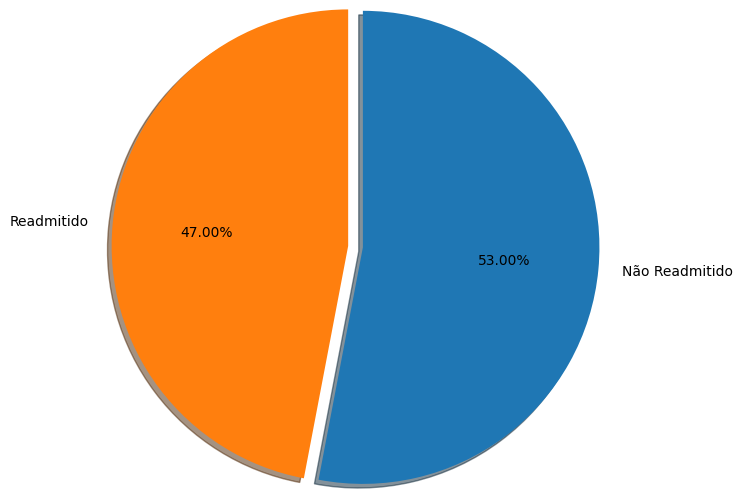

In [135]:
# Vamos visualizar de forma gráfica

# Percentual de cada valor da variável alvo
percentual = round(df_dsa.readmitted.value_counts() / len(df_dsa.index) * 100, 0)

# Labels
labels = ['Não Readmitido', 'Readmitido']

# Plot
plt.axis("equal")
plt.pie(percentual ,
        labels = labels,
        radius = 1.6,
        autopct = '%1.2f%%',
        explode = [0.05,0.05],
        startangle = 90,
        shadow = True,
        counterclock = False,
        pctdistance = 0.6)
plt.show()

### **Recategorização de varíavel**
Como tratamis as variáveis

In [136]:
# Tipo de variável
df_dsa.age.dtype

dtype('O')

In [137]:
# Total de pacientes por faixa etária
df_dsa.groupby('age').size()

,0
age,
[0-10),65
[10-20),466
[20-30),1478
[30-40),3548
[40-50),9265
[50-60),16697
[60-70),21809
[70-80),25305
[80-90),16702


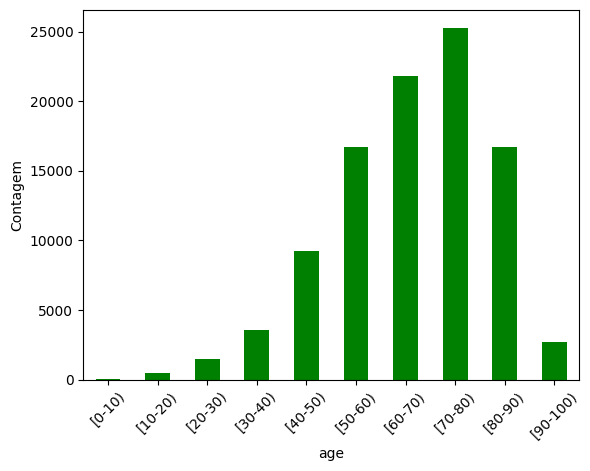

In [138]:
# Vamos verificar a variável que representa a faixa etária dos pacientes

# Agrupando os dados por idade e plotando o gráfico de barras
df_dsa.groupby('age').size().plot(kind = 'bar', color = 'green')

# Adicionando rótulo ao eixo y
plt.ylabel('Contagem')

# Rotacionando os rótulos do eixo x
plt.xticks(rotation = 45)

# Exibindo o gráfico
plt.show()

Podemos perceber que a maioria dos pacientes está na faixa entre 50 e 90 anos.

Existem diferentes maneiras de lidar com essa variável. O conjunto de dados nos dá a idade apenas como categorias nas faixas de 10 anos, portanto, não sabemos a idade exata de cada paciente.

Podemos adotar duas abordagens:

1- Se queremos ver o efeito do aumento da idade na readmissão do paciente, mesmo que de maneira grosseira, podemos assumir que a idade do paciente, em média, esteja no ponto médio da categoria de idade. Por exemplo, se a categoria de idade do paciente é de 20 a 30 anos, assumimos a idade = 25 anos. Então, convertemos categorias de idade em pontos médios, resultando em uma variável numérica.

2- Podemos recategorizar a variável, distribuindo os pacientes por um número menor de faixas e manter a variável como categórica. Nesse caso, poderíamos avaliar o risco por faixa etária e não por idade.

Adotaremos a opção 2 pois altera menos a informação contida nos dados.

In [139]:
# Recategorizamos 'idade' para que a população seja distribuída de maneira mais uniforme

# Classificamos como faixa de 0-50 pacientes de até 50 anos
df_dsa['age'] = pd.Series(['[0-50)' if val in ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)'] else val
                          for val in df_dsa['age']], index = df_dsa.index)

# Acima de 80 anos ficam na faixa de 80-100
df_dsa['age'] = pd.Series(['[80-100)' if val in ['[80-90)', '[90-100)'] else val
                          for val in df_dsa['age']], index = df_dsa.index)

# As outras faixas são mantidas

In [140]:
# Tipo ds variável
df_dsa.age.dtype

dtype('O')

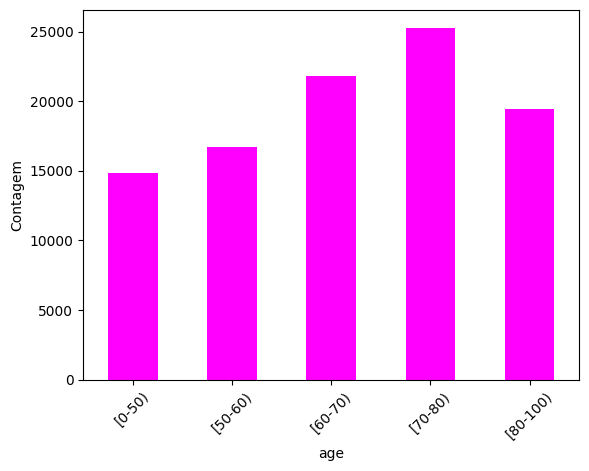

In [141]:
# Vamos verificar a variável que representa a faixa etária dos pacientes

# Agrupando os dados por idade e plotando o gráfico de barras
df_dsa.groupby('age').size().plot(kind = 'bar', color = 'magenta')

# Adicionando rótulo ao eixo y
plt.ylabel('Contagem')

# Rotacionando os rótulos do eixo x
plt.xticks(rotation = 45)

# Exibindo o gráfico
plt.show()

## Como tratamos variáveis do tipo ID? Seguiremos com a Recategorização de Variável.

### As variáveis 'admission_type_id', 'harge_disposition_id' e 'admission_source_id' têm valores com significado semelhante. Eles podem ser mesclados para ter menos valores.

In [142]:
df_dsa.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
1,149190,55629189,Caucasian,Female,[0-50),1,1,7,3,59,...,No,Up,No,No,No,No,No,Ch,Yes,1
2,64410,86047875,AfricanAmerican,Female,[0-50),1,1,7,2,11,...,No,No,No,No,No,No,No,No,Yes,0
3,500364,82442376,Caucasian,Male,[0-50),1,1,7,2,44,...,No,Up,No,No,No,No,No,Ch,Yes,0
4,16680,42519267,Caucasian,Male,[0-50),1,1,7,1,51,...,No,Steady,No,No,No,No,No,Ch,Yes,0
5,35754,82637451,Caucasian,Male,[50-60),2,1,2,3,31,...,No,Steady,No,No,No,No,No,No,Yes,1


Variável **admission_type_id**

In [143]:
df_dsa.admission_type_id.unique()

array([1, 2, 3, 6, 4, 5, 8, 7])

In [144]:
df_dsa.admission_type_id.nunique()

8

In [145]:
df_dsa.admission_type_id.value_counts()

,count
admission_type_id,
1,52178
3,18193
2,17543
6,5135
5,4661
8,312
7,20
4,10


In [146]:
# A variável 'admissions_type_id' contém 8 níveis
# Reduziremos os niveis 'admissions_type_id' para duas categorias
df_dsa['admission_type_id'] = pd.Series(['Emergencia' if val == 1 else 'Outro'
                                       for val in df_dsa ['admission_type_id']], index = df_dsa.index)

In [147]:
df_dsa.admission_type_id.nunique()

2

In [148]:
df_dsa.admission_type_id.value_counts()

,count
admission_type_id,
Emergencia,52178
Outro,45874


variável **discharge_disposition-id**

In [149]:
df_dsa.discharge_disposition_id.unique()

array([ 1,  3,  6,  2,  5, 11,  7, 25, 10,  4, 14, 18,  8, 13, 12, 16, 17,
       22, 23,  9, 20, 15, 24, 28, 19, 27])

In [150]:
df_dsa.discharge_disposition_id.nunique()

26

In [151]:
df_dsa.discharge_disposition_id.value_counts()

,count
discharge_disposition_id,
1,57609
3,13564
6,12626
18,3624
2,2049
22,1970
11,1606
5,1127
25,941


In [152]:
# A variável 'discharge_disposition_id' contém 26 níveis
# Reduziremos os níveis de 'discharge_disposition_id' para duas categorias
df_dsa['discharge_disposition_id'] = pd.Series(['Casa' if val == 1 else 'Outro'
                                              for val in df_dsa['discharge_disposition_id']], index = df_dsa.index)

In [153]:
df_dsa.discharge_disposition_id.nunique()

2

In [154]:
df_dsa.discharge_disposition_id.value_counts()

,count
discharge_disposition_id,
Casa,57609
Outro,40443


Variável **admission_source_id**

In [155]:
df_dsa.admission_source_id.unique()

array([ 7,  2,  4,  1,  5,  6, 20,  3, 17,  8,  9, 14, 10, 22, 11, 25, 13])

In [156]:
df_dsa.admission_source_id.nunique()

17

In [157]:
df_dsa.admission_source_id.value_counts()

,count
admission_source_id,
7,55951
1,28355
17,6602
4,2945
6,1893
2,1031
5,846
3,179
20,160


In [158]:
# A variável 'admission_source_id' contém 17 níveis
# # Reduziremos os níveis de 'admission_source_id' para três categorias
df_dsa['admission_source_id'] = pd.Series(['Sala_Emergencia' if val == 7 else 'Recomendacao' if val == 1 else 'Outro'
                                              for val in df_dsa['admission_source_id']], index = df_dsa.index)


In [159]:
df_dsa.admission_source_id.nunique()

3

In [160]:
df_dsa.admission_source_id.value_counts()

,count
admission_source_id,
Sala_Emergencia,55951
Recomendacao,28355
Outro,13746


## Engenharia de Atributos com Base no Conhecimento de Domínio
Como tratamos as variáveis 'diag_1', 'diag_2' e 'diag_3' que representam o diagnóstico médico?

In [161]:
# Visualiza os dados
df_dsa[['diag_1', 'diag_2', 'diag_3']].head()

,diag_1,diag_2,diag_3
1,276,250.01,255
2,648,250,V27
3,8,250.43,403
4,197,157,250
5,414,411,250


O conjunto de dados contém até três diagnósticos para um determinado paciente (primário, secundário e adicional).

No entanto, cada um deles tem códigos ICD-9 exclusivos e é extremamente difícil incluí-los no modelo e interpretar de forma significativa.

Portanto, reduziremos esses códigos de diagnóstico para 4 categorias considerando a comorbidade.

Códigos ICD-9 (International Classification of Diseases ou Código Internacional de Doenças):

https://en.wikipedia.org/wiki/List_of_ICD-9_codes

http://www.icd9data.com/2013/Volume1/default.htm

https://icd.codes/icd9cm

https://www.cms.gov/Medicare/Coding/ICD9ProviderDiagnosticCodes/codes

In [162]:
# Concatena 3 variáveis em um dataframe
diagnostico = df_dsa[['diag_1', 'diag_2', 'diag_3']]

In [163]:
# Visualiza os dados
diagnostico.head()

,diag_1,diag_2,diag_3
1,276,250.01,255
2,648,250,V27
3,8,250.43,403
4,197,157,250
5,414,411,250


In [164]:
# Verifica se há valores ausentes
diagnostico.isnull().any()

,0
diag_1,False
diag_2,False
diag_3,False


# Calculando a Comorbidade com Engenharia de Atributos

Defining Comorbidity: Implications for Understanding Health and Health Services:

https://www.ncbi.nlm.nih.gov/pmc/articles/PMC2713155/

Comorbidity: Substance Use Disorders and Other Mental Illnesses:

https://www.drugabuse.gov/publications/drugfacts/comorbidity-substance-use-disorders-other-mental-illnesses

Em termos simples, comorbidade refere-se à presença de mais de um distúrbio na mesma pessoa. Por exemplo, se uma pessoa é diagnosticada com transtorno de ansiedade social (SAD) e transtorno depressivo maior (MDD), diz-se que ela possui transtornos depressivos e ansiosos comórbidos (significando de coexistentes).

Outras condições que parecem se sobrepor incluem doenças físicas como diabetes, doenças cardiovasculares, câncer, doenças infecciosas e demência. Os transtornos mentais que tendem a mostrar comorbidade também incluem transtornos alimentares, transtornos de ansiedade e abuso de substâncias.

Não é incomum que as pessoas sofram de dois distúrbios ou doenças ao mesmo tempo. A comorbidade na doença mental pode incluir uma situação em que uma pessoa recebe um diagnóstico médico seguido pelo diagnóstico de um transtorno mental (ou vice-versa) ou pode envolver o diagnóstico de um transtorno mental seguido pelo diagnóstico de outro transtorno mental.

Um grande estudo epidemiológico nacional transversal de 2009 sobre comorbidade de transtornos mentais na atenção primária na Espanha, publicado no Journal of Affective Disorders, mostrou que entre uma amostra de 7936 pacientes adultos, cerca da metade tinha mais de um distúrbio psiquiátrico.

Prevalence and comorbidity of common mental disorders in primary care

Além disso, uma Pesquisa Nacional de Comorbidade dos EUA, 51% dos pacientes com diagnóstico de depressão também tiveram pelo menos um transtorno de ansiedade e apenas 26% deles não tiveram nenhum outro transtorno mental. No entanto, no Estágio Inicial de Desenvolvimento da Psicopatologia, 48,6% dos pacientes com diagnóstico de depressão também apresentaram pelo menos um transtorno de ansiedade e 34,8% deles não possuíam outro transtorno mental.

‘Psychiatric comorbidity’: an artefact of current diagnostic systems?

Acesse o site abaixo para buscar detalhes sobre os padrões de expressões regulares em Python:

https://www.w3schools.com/python/python_regex.asp

In [165]:
# Visualiza os dados
diagnostico.head(10)

,diag_1,diag_2,diag_3
1,276,250.01,255
2,648,250,V27
3,8,250.43,403
4,197,157,250
5,414,411,250
6,414,411,V45
7,428,492,250
8,398,427,38
9,434,198,486
10,250.7,403,996


In [166]:
# Função que calcula a Comorbidade
def calcula_comorbidade(row):

    # Código 250 indica diabetes
    codigos_doenca_diabetes = "^[2][5][0]"

    # Códigos 39x (x = valor entre 0 e 9)
    # Códigos 4zx (z = valor entre 0 e 6 e x = valor entre 0 e 9)
    # Esses códigos indicam problemas circulatórios
    codigos_doenca_circulatorios = "^[3][9][0-9]|^[4][0-6][0-9]"

    # Inicializa variável de retorno
    valor = 0

    # Valor 0 indica que:
    # Diabetes e problemas circulatórios não foram detectados de forma simultânea no paciente
    if(not(bool(re.match(codigos_doenca_diabetes, str(np.array(row['diag_1']))))) and
       not(bool(re.match(codigos_doenca_diabetes, str(np.array(row['diag_2']))))) and
       not(bool(re.match(codigos_doenca_diabetes, str(np.array(row['diag_3'])))))) and (not(
        bool(re.match(codigos_doenca_circulatorios, str(np.array(row['diag_1']))))) and not(
        bool(re.match(codigos_doenca_circulatorios, str(np.array(row['diag_2']))))) and not(
        bool(re.match(codigos_doenca_circulatorios, str(np.array(row['diag_3'])))))):
        valor = 0

    # Valor 1 indica que:
    # Pelo menos um diagnóstico de diabetes e problemas circulatórios foram detectados de forma
    # simultânea no paciente
    if(bool(re.match(codigos_doenca_diabetes, str(np.array(row['diag_1'])))) or
       bool(re.match(codigos_doenca_diabetes, str(np.array(row['diag_2'])))) or
       bool(re.match(codigos_doenca_diabetes, str(np.array(row['diag_3']))))) and (not(
        bool(re.match(codigos_doenca_circulatorios, str(np.array(row['diag_1']))))) and not(
        bool(re.match(codigos_doenca_circulatorios, str(np.array(row['diag_2']))))) and not(
        bool(re.match(codigos_doenca_circulatorios, str(np.array(row['diag_3'])))))):
        valor = 1

    # Valor 2 indica que:
    # Diabetes e pelo menos um diagnóstico de problemas circulatórios foram detectados de forma
    # simultânea no paciente
    if(not(bool(re.match(codigos_doenca_diabetes, str(np.array(row['diag_1']))))) and
       not(bool(re.match(codigos_doenca_diabetes, str(np.array(row['diag_2']))))) and
       not(bool(re.match(codigos_doenca_diabetes, str(np.array(row['diag_3'])))))) and (
        bool(re.match(codigos_doenca_circulatorios, str(np.array(row['diag_1'])))) or
        bool(re.match(codigos_doenca_circulatorios, str(np.array(row['diag_2'])))) or
        bool(re.match(codigos_doenca_circulatorios, str(np.array(row['diag_3']))))):
        valor = 2

    # Valor 3 indica que:
    # Pelo menos um diagnóstico de diabetes e pelo menos um diagnóstico de problemas circulatórios
    # foram detectados de forma simultânea no paciente
    if(bool(re.match(codigos_doenca_diabetes, str(np.array(row['diag_1'])))) or
       bool(re.match(codigos_doenca_diabetes, str(np.array(row['diag_2'])))) or
       bool(re.match(codigos_doenca_diabetes, str(np.array(row['diag_3']))))) and (
        bool(re.match(codigos_doenca_circulatorios, str(np.array(row['diag_1'])))) or
        bool(re.match(codigos_doenca_circulatorios, str(np.array(row['diag_2'])))) or
        bool(re.match(codigos_doenca_circulatorios, str(np.array(row['diag_3']))))):
        valor = 3

    return valor

Agora aplica a função dados

In [167]:
 %%time
 df_dsa['comorbidade'] = diagnostico.apply(calcula_comorbidade, axis = 1)

CPU times: user 10.1 s, sys: 8.08 ms, total: 10.1 s
Wall time: 11.2 s


In [168]:
# Shape
df_dsa.shape

(98052, 46)

In [169]:
# Visualiaza os dados
df_dsa.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,comorbidade
1,149190,55629189,Caucasian,Female,[0-50),Emergencia,Casa,Sala_Emergencia,3,59,...,Up,No,No,No,No,No,Ch,Yes,1,1
2,64410,86047875,AfricanAmerican,Female,[0-50),Emergencia,Casa,Sala_Emergencia,2,11,...,No,No,No,No,No,No,No,Yes,0,1
3,500364,82442376,Caucasian,Male,[0-50),Emergencia,Casa,Sala_Emergencia,2,44,...,Up,No,No,No,No,No,Ch,Yes,0,3
4,16680,42519267,Caucasian,Male,[0-50),Emergencia,Casa,Sala_Emergencia,1,51,...,Steady,No,No,No,No,No,Ch,Yes,0,1
5,35754,82637451,Caucasian,Male,[50-60),Outro,Casa,Outro,3,31,...,Steady,No,No,No,No,No,No,Yes,1,3


In [170]:
# Valores únicos
df_dsa['comorbidade'].unique()

array([1, 3, 2, 0])

In [171]:
# Valores úncios contagem
df_dsa['comorbidade'].value_counts()

,count
comorbidade,
2,39807
0,22389
1,17984
3,17872


In [172]:
# Drop das variáveis individuais
df_dsa.drop(['diag_1','diag_2','diag_3'], axis = 1, inplace = True)

In [173]:
# Calcula o percentual de comorbidade por tipo e por classe da variável alvo
percent_com = pd.crosstab(df_dsa.comorbidade, df_dsa.readmitted , normalize = 'index') * 100

In [174]:
percent_com

readmitted,0,1
comorbidade,,
0,55.509402,44.490598
1,53.831183,46.168817
2,51.782350,48.217650
3,53.799239,46.200761


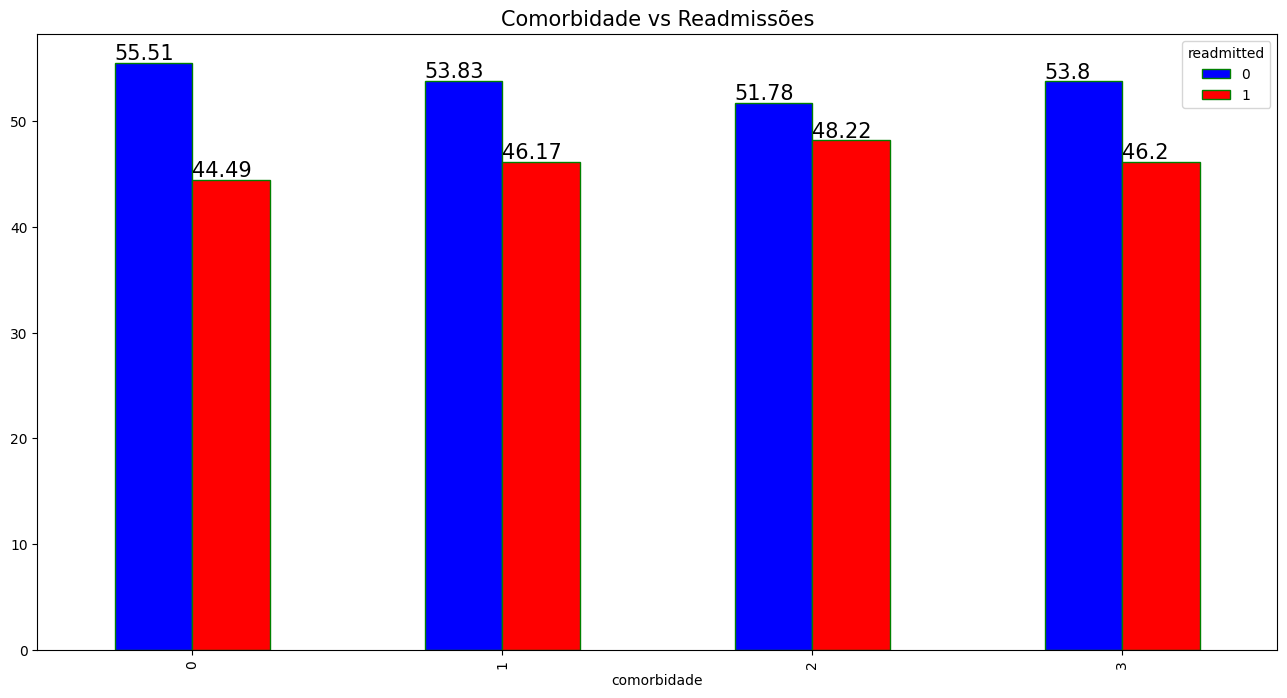

In [175]:
# Plot

# Prepara a figura a partir dos dados
fig = percent_com.plot(kind = 'bar',
                       figsize = (16, 8),
                       width = 0.5,
                       edgecolor = 'g',
                       color = ['b','r'])

# Desenha cada grupo
for i in fig .patches:
    fig.text(i.get_x() + 0.00,
             i.get_height() + 0.3,
             str(round((i.get_height()), 2)),
             fontsize = 15,
             color = 'black',
             rotation = 0)

# Título e Print
plt.title("Comorbidade vs Readmissões", fontsize = 15)
plt.show()

## **Engeharia de Atributos - Recoding d variáveis categóricas**
**Variáveis de dosagem de medicamantos e agrupamentos de variáveis**

Verificando nosso conjunto de dados até aqui:

In [176]:
df_dsa.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,comorbidade
1,149190,55629189,Caucasian,Female,[0-50),Emergencia,Casa,Sala_Emergencia,3,59,...,Up,No,No,No,No,No,Ch,Yes,1,1
2,64410,86047875,AfricanAmerican,Female,[0-50),Emergencia,Casa,Sala_Emergencia,2,11,...,No,No,No,No,No,No,No,Yes,0,1
3,500364,82442376,Caucasian,Male,[0-50),Emergencia,Casa,Sala_Emergencia,2,44,...,Up,No,No,No,No,No,Ch,Yes,0,3
4,16680,42519267,Caucasian,Male,[0-50),Emergencia,Casa,Sala_Emergencia,1,51,...,Steady,No,No,No,No,No,Ch,Yes,0,1
5,35754,82637451,Caucasian,Male,[50-60),Outro,Casa,Outro,3,31,...,Steady,No,No,No,No,No,No,Yes,1,3


In [177]:
df_dsa.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'num_lab_procedures', 'num_procedures',
       'num_medications', 'number_outpatient', 'number_emergency',
       'number_inpatient', 'number_diagnoses', 'metformin', 'repaglinide',
       'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide',
       'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
       'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
       'examide', 'citoglipton', 'insulin', 'glyburide-metformin',
       'glipizide-metformin', 'glimepiride-pioglitazone',
       'metformin-rosiglitazone', 'metformin-pioglitazone', 'change',
       'diabetesMed', 'readmitted', 'comorbidade'],
      dtype='object')

### O conjunto de dados contém 23 recursos para 23 medicamentos que indicam, para cada um deles, se uma alteração no medicamento foi feita ou não durante a atual internação do paciente.

Vamos plotar algumas variáveis que indicam uso de medicamento.

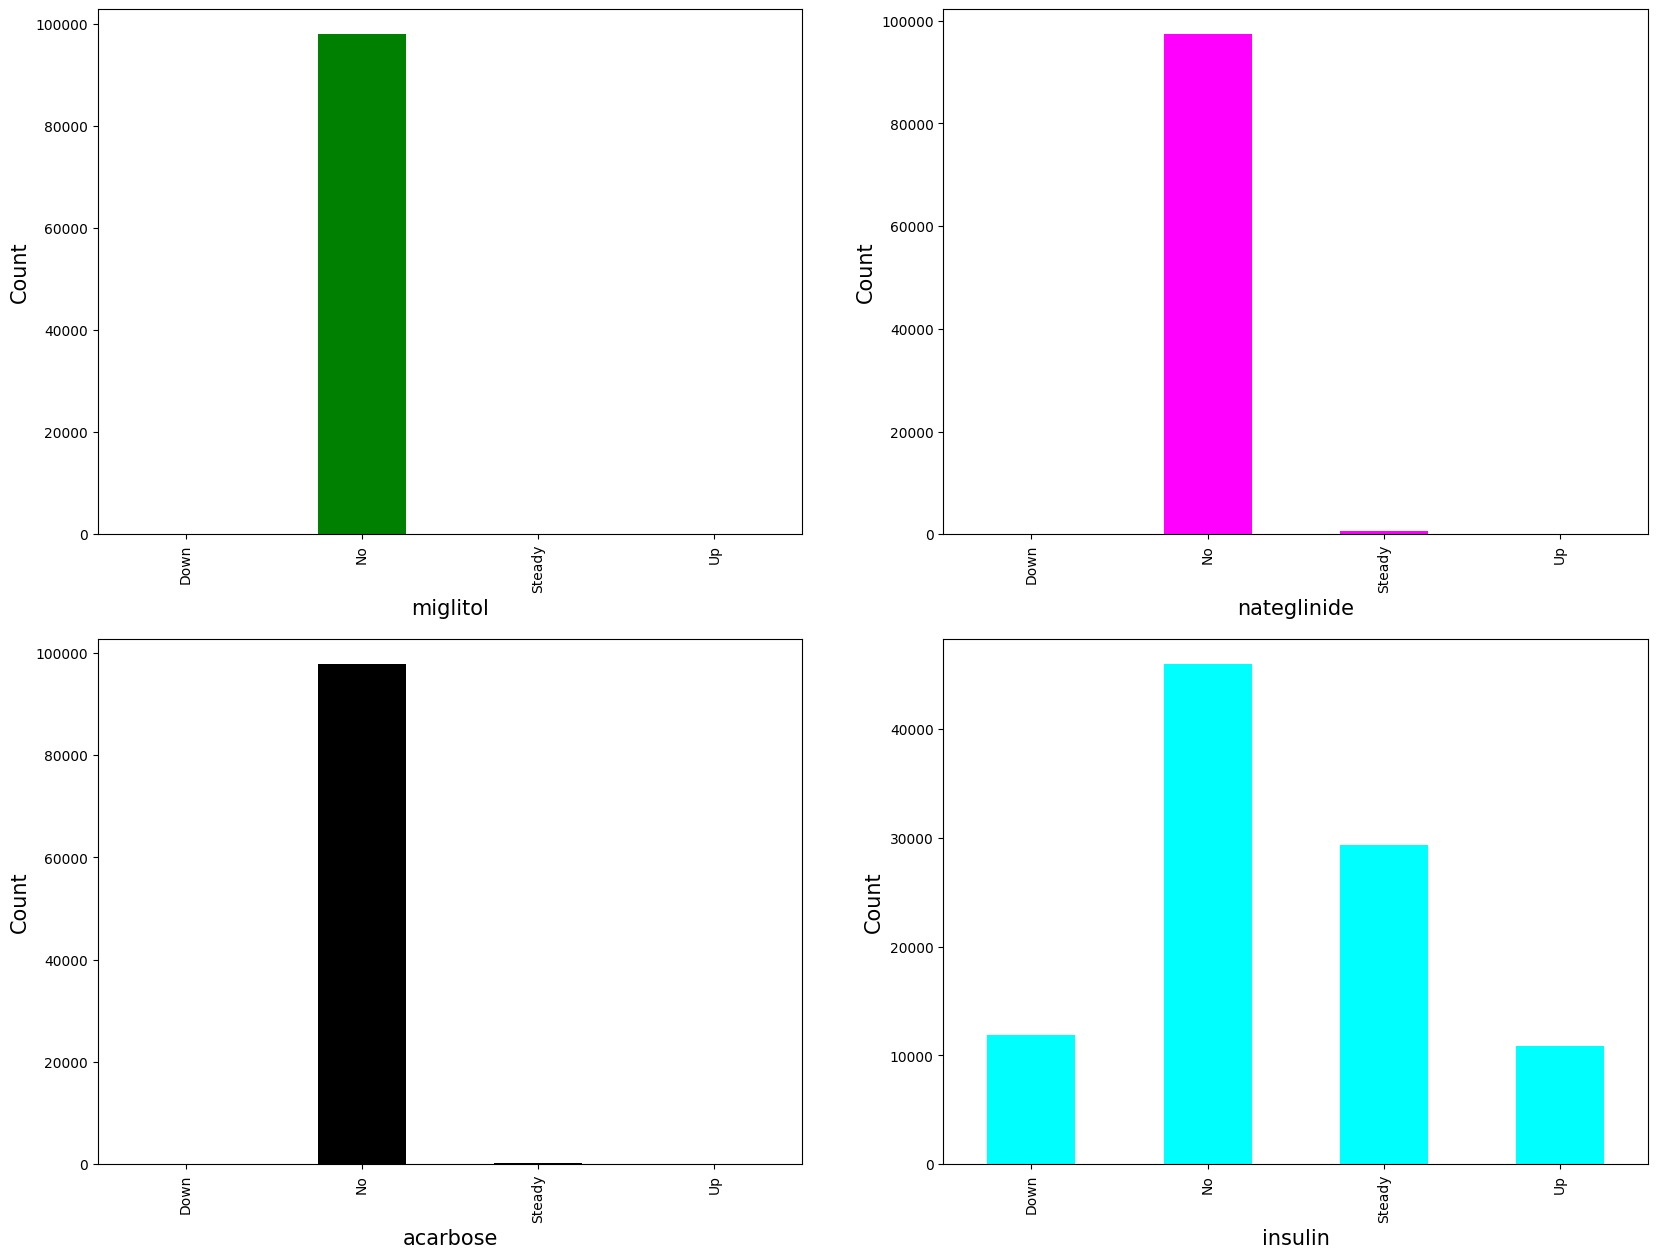

In [178]:
# Plot
fig = plt.figure(figsize = (20,15))

ax1 = fig.add_subplot(221)
ax1 = df_dsa.groupby('miglitol').size().plot(kind = 'bar', color = 'green')
plt.xlabel('miglitol', fontsize = 15)
plt.ylabel('Count', fontsize = 15)

ax2 = fig.add_subplot(222)
ax2 = df_dsa.groupby('nateglinide').size().plot(kind = 'bar', color = 'magenta')
plt.xlabel('nateglinide', fontsize = 15)
plt.ylabel('Count', fontsize = 15)

ax3 = fig.add_subplot(223)
ax3 = df_dsa.groupby('acarbose').size().plot(kind = 'bar', color = 'black')
plt.xlabel('acarbose', fontsize = 15)
plt.ylabel('Count', fontsize = 15)

ax4 = fig.add_subplot(224)
ax4 = df_dsa.groupby('insulin').size().plot(kind = 'bar', color = 'cyan')
plt.xlabel('insulin', fontsize = 15)
plt.ylabel('Count', fontsize = 15)
plt.show();

## Podemos contar quantas alterações do medicamento foram feitas no total para cada paciente e criamos um novo atributo. Isso pode ajudar a descobrir uma relação com o número de alterações, independentemente de qual medicamento foi alterado.

## Além disso, podemos criar um novo atributo indicando o total de medicamentos que cada paciente consumiu durante a internação. E então avaliamos se há relação do total com a readmissão.

In [179]:
# Lista com os nomes das variáveis de medicamentos (3 variáveis já tinham sido removidas)
medicamentos = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide',
                'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol',
                'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin',
                'glimepiride-pioglitazone', 'metformin-pioglitazone']

In [180]:
# Loop para ajudar os valores das variáveis
for col in medicamentos:
    if col in df_dsa.columns:
        colname = str(col) + 'temp'
        df_dsa[colname] = df_dsa[col].apply(lambda x: 0 if (x == 'No' or x == 'Steady') else 1)

In [181]:
df_dsa.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,rosiglitazonetemp,acarbosetemp,miglitoltemp,troglitazonetemp,tolazamidetemp,insulintemp,glyburide-metformintemp,glipizide-metformintemp,glimepiride-pioglitazonetemp,metformin-pioglitazonetemp
1,149190,55629189,Caucasian,Female,[0-50),Emergencia,Casa,Sala_Emergencia,3,59,...,0,0,0,0,0,1,0,0,0,0
2,64410,86047875,AfricanAmerican,Female,[0-50),Emergencia,Casa,Sala_Emergencia,2,11,...,0,0,0,0,0,0,0,0,0,0
3,500364,82442376,Caucasian,Male,[0-50),Emergencia,Casa,Sala_Emergencia,2,44,...,0,0,0,0,0,1,0,0,0,0
4,16680,42519267,Caucasian,Male,[0-50),Emergencia,Casa,Sala_Emergencia,1,51,...,0,0,0,0,0,0,0,0,0,0
5,35754,82637451,Caucasian,Male,[50-60),Outro,Casa,Outro,3,31,...,0,0,0,0,0,0,0,0,0,0


In [182]:
# Criar uma variável para receber a contagem por paciente
df_dsa['num_alt_dosagem_med'] = 0

In [183]:
# Contagem de modificações na dosagem de medicamentos
for col in medicamentos:
    if col in df_dsa.columns:
        colname = str(col) + 'temp'
        df_dsa['num_alt_dosagem_med'] = df_dsa['num_alt_dosagem_med'] + df_dsa[colname]
        del df_dsa[colname]

In [184]:
# Verifica o total por modificações na dosagem de medicamentos
df_dsa.num_alt_dosagem_med.value_counts()

,count
num_alt_dosagem_med,
0,71309
1,25350
2,1281
3,107
4,5


In [185]:
df_dsa.head()


,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,comorbidade,num_alt_dosagem_med
1,149190,55629189,Caucasian,Female,[0-50),Emergencia,Casa,Sala_Emergencia,3,59,...,No,No,No,No,No,Ch,Yes,1,1,1
2,64410,86047875,AfricanAmerican,Female,[0-50),Emergencia,Casa,Sala_Emergencia,2,11,...,No,No,No,No,No,No,Yes,0,1,0
3,500364,82442376,Caucasian,Male,[0-50),Emergencia,Casa,Sala_Emergencia,2,44,...,No,No,No,No,No,Ch,Yes,0,3,1
4,16680,42519267,Caucasian,Male,[0-50),Emergencia,Casa,Sala_Emergencia,1,51,...,No,No,No,No,No,Ch,Yes,0,1,0
5,35754,82637451,Caucasian,Male,[50-60),Outro,Casa,Outro,3,31,...,No,No,No,No,No,No,Yes,1,3,0


Vamos alterar o valor das colunas dos medicamentos para refletir se esse medicamento está sendo administrado a um paciente ou não.

In [186]:
# Recoding das colunas de medicamentos
for col in medicamentos:
    if col in df_dsa.columns:
        df_dsa[col] = df_dsa[col].replace('No', 0)
        df_dsa[col] = df_dsa[col].replace('Steady', 1)
        df_dsa[col] = df_dsa[col].replace('Up', 1)
        df_dsa[col] = df_dsa[col].replace('Down', 1)

Agora, criamos mais uma coluna para refletir quantos medicamentos estão sendo administrados a um paciente.

In [187]:
# Variável com a contagem de medicamentos por paciente
df_dsa['num_med'] = 0

In [188]:
# Carrega a nova variável
for col in medicamentos:
    if col in df_dsa.columns:
        df_dsa['num_med'] = df_dsa['num_med'] + df_dsa[col]

In [189]:
# Verifica o total de medicamentos
df_dsa.num_med.value_counts()

,count
num_med,
1,45447
0,22702
2,21056
3,7485
4,1300
5,57
6,5


Depois de criar essas duas colunas, podemos remover as colunas dos medicamentos.

In [190]:
# Remove as colunas de medicamentos
df_dsa = df_dsa.drop(columns = medicamentos)

In [191]:
# Shape
df_dsa.shape

(98052, 25)

In [192]:
df_dsa.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,number_diagnoses,examide,citoglipton,metformin-rosiglitazone,change,diabetesMed,readmitted,comorbidade,num_alt_dosagem_med,num_med
1,149190,55629189,Caucasian,Female,[0-50),Emergencia,Casa,Sala_Emergencia,3,59,...,9,No,No,No,Ch,Yes,1,1,1,1
2,64410,86047875,AfricanAmerican,Female,[0-50),Emergencia,Casa,Sala_Emergencia,2,11,...,6,No,No,No,No,Yes,0,1,0,1
3,500364,82442376,Caucasian,Male,[0-50),Emergencia,Casa,Sala_Emergencia,2,44,...,7,No,No,No,Ch,Yes,0,3,1,1
4,16680,42519267,Caucasian,Male,[0-50),Emergencia,Casa,Sala_Emergencia,1,51,...,5,No,No,No,Ch,Yes,0,1,0,2
5,35754,82637451,Caucasian,Male,[50-60),Outro,Casa,Outro,3,31,...,9,No,No,No,No,Yes,1,3,0,1


In [193]:
# Variáveis
df_dsa.dtypes

,0
encounter_id,int64
patient_nbr,int64
race,object
gender,object
age,object
admission_type_id,object
discharge_disposition_id,object
admission_source_id,object
time_in_hospital,int64
num_lab_procedures,int64


**Recoding de Variáveis Categóricas**

Vamos fazer o recoding de algumas variáveis categóricas.

In [194]:
df_dsa['change'].value_counts()

,count
change,
No,52774
Ch,45278


In [195]:
df_dsa['gender'].value_counts()

,count
gender,
Female,52833
Male,45219


In [196]:
df_dsa['diabetesMed'].value_counts()

,count
diabetesMed,
Yes,75350
No,22702


In [197]:
# Recoding de variável categóricas binárias
df_dsa['change'] = df_dsa['change'].replace('Ch', 1)
df_dsa['change'] = df_dsa['change'].replace('No', 0)
df_dsa['gender'] = df_dsa['gender'].replace('Male', 1)
df_dsa['gender'] = df_dsa['gender'].replace('Female', 0)
df_dsa['diabetesMed'] = df_dsa['diabetesMed'].replace('Yes', 1)
df_dsa['diabetesMed'] = df_dsa['diabetesMed'].replace('No', 0)

In [198]:
df_dsa.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,number_diagnoses,examide,citoglipton,metformin-rosiglitazone,change,diabetesMed,readmitted,comorbidade,num_alt_dosagem_med,num_med
1,149190,55629189,Caucasian,0,[0-50),Emergencia,Casa,Sala_Emergencia,3,59,...,9,No,No,No,1,1,1,1,1,1
2,64410,86047875,AfricanAmerican,0,[0-50),Emergencia,Casa,Sala_Emergencia,2,11,...,6,No,No,No,0,1,0,1,0,1
3,500364,82442376,Caucasian,1,[0-50),Emergencia,Casa,Sala_Emergencia,2,44,...,7,No,No,No,1,1,0,3,1,1
4,16680,42519267,Caucasian,1,[0-50),Emergencia,Casa,Sala_Emergencia,1,51,...,5,No,No,No,1,1,0,1,0,2
5,35754,82637451,Caucasian,1,[50-60),Outro,Casa,Outro,3,31,...,9,No,No,No,0,1,1,3,0,1


Alguns pacientes no conjunto de dados tiveram mais de um encontro (consulta).

Não podemos contá-los como encontros independentes, porque isso influencia os resultados para aqueles pacientes que tiveram vários encontros. Assim, tentamos várias técnicas para recolher e consolidar vários encontros para o mesmo paciente, como:

* Considerar a permanência média no hospital em vários encontros.
* Considerar a porcentagem de alterações na medicação em vários encontros.
* Considerar o número total de encontros para substituir o ID exclusivo do encontro.
* Considerar a combinação de diagnósticos em vários encontros como uma lista.
Por fim, o ideal foi deixar apenas um registro de encontro para cada paciente e optamos por manter o primeiro.

In [201]:
# Removendo duplicidades por id de pacientes, mantendo o primeiro registro
df_dsa = df_dsa.drop_duplicates(subset = 'patient_nbr', keep = 'first')

In [202]:
# Shape
df_dsa.shape

(68629, 25)

In [203]:
df_dsa.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,number_diagnoses,examide,citoglipton,metformin-rosiglitazone,change,diabetesMed,readmitted,comorbidade,num_alt_dosagem_med,num_med
1,149190,55629189,Caucasian,0,[0-50),Emergencia,Casa,Sala_Emergencia,3,59,...,9,No,No,No,1,1,1,1,1,1
2,64410,86047875,AfricanAmerican,0,[0-50),Emergencia,Casa,Sala_Emergencia,2,11,...,6,No,No,No,0,1,0,1,0,1
3,500364,82442376,Caucasian,1,[0-50),Emergencia,Casa,Sala_Emergencia,2,44,...,7,No,No,No,1,1,0,3,1,1
4,16680,42519267,Caucasian,1,[0-50),Emergencia,Casa,Sala_Emergencia,1,51,...,5,No,No,No,1,1,0,1,0,2
5,35754,82637451,Caucasian,1,[50-60),Outro,Casa,Outro,3,31,...,9,No,No,No,0,1,1,3,0,1


In [204]:
# Salvando o dataset
df_dsa.to_csv('resultado_Projeto7.csv', index = False)

In [205]:
%watermark -a "Eduardo Lyrio"

Author: Eduardo Lyrio



In [206]:
%watermark -v -m

Python implementation: CPython
Python version       : 3.12.12
IPython version      : 7.34.0

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.6.105+
Machine     : x86_64
Processor   : x86_64
CPU cores   : 2
Architecture: 64bit



In [207]:
%watermark --iversions

matplotlib: 3.10.0
numpy     : 2.0.2
pandas    : 2.2.2
re        : 2.2.1
seaborn   : 0.13.2

